In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss

In [84]:
df = pd.read_csv('./dataset/Predict Hair Fall.csv')
df.head()

,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,133992,Yes,No,No Data,No Data,Magnesium deficiency,Moderate,19,Yes,Yes,No,No,0
1,148393,No,No,Eczema,Antibiotics,Magnesium deficiency,High,43,Yes,Yes,No,No,0
2,155074,No,No,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,Yes,Yes,No,Yes,0
3,118261,Yes,Yes,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,Yes,Yes,No,No,0
4,111915,No,No,Psoriasis,Accutane,Iron deficiency,Moderate,30,No,Yes,Yes,No,1


In [85]:
print(df.isnull().sum())

Id                           0
Genetics                     0
Hormonal Changes             0
Medical Conditions           0
Medications & Treatments     0
Nutritional Deficiencies     0
Stress                       0
Age                          0
Poor Hair Care Habits        0
Environmental Factors        0
Smoking                      0
Weight Loss                  0
Hair Loss                    0
dtype: int64


In [86]:
binary_cols = [
    'Genetics', 
    'Hormonal Changes', 
    'Poor Hair Care Habits ', 
    'Environmental Factors', 
    'Smoking', 
    'Weight Loss '
]

# Define the mapping: 'Yes' to 1, 'No' to 0
mapping = {'Yes': 1, 'No': 0}

for col in binary_cols:
    df[col] = df[col].replace(mapping)

df.head()



,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss
0,133992,1,0,No Data,No Data,Magnesium deficiency,Moderate,19,1,1,0,0,0
1,148393,0,0,Eczema,Antibiotics,Magnesium deficiency,High,43,1,1,0,0,0
2,155074,0,0,Dermatosis,Antifungal Cream,Protein deficiency,Moderate,26,1,1,0,1,0
3,118261,1,1,Ringworm,Antibiotics,Biotin Deficiency,Moderate,46,1,1,0,0,0
4,111915,0,0,Psoriasis,Accutane,Iron deficiency,Moderate,30,0,1,1,0,1


In [87]:


HIGH_CARDINALITY_COLS = [
    'Medical Conditions', 
    'Medications & Treatments', 
    'Nutritional Deficiencies '
]

# Combine any category that appears in less than 5% of the data into 'RARE'.
RARITY_THRESHOLD = 0.05 
MISSING_VALUE_STR = 'No Data'

def group_rare_categories(df, column, threshold, missing_str):
    """
    Groups categories that are below a certain frequency threshold into a 
    'RARE' group and standardizes missing values.
    """
    # print(f"Processing column: {column}")
    
    df[column] = df[column].replace(missing_str, 'MISSING')
    
    # value_counts = df[column].value_counts(normalize=True)
    # rare_categories = value_counts[value_counts < threshold].index.tolist()
    # print(f"Old unique values for {column}: {df[column].nunique()}")
    # df[column] = df[column].replace(rare_categories, 'RARE')
    # print(f"New unique values for {column}: {df[column].nunique()}")
    # print(df[column].value_counts(normalize=True).round(3))
    # print("-" * 50)
    
    return df

for col in HIGH_CARDINALITY_COLS:
    df = group_rare_categories(df, col, RARITY_THRESHOLD, MISSING_VALUE_STR)



In [88]:
stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress'] = df['Stress'].replace(stress_mapping).astype(int)

In [89]:
df['Age_Group'], age_bins = pd.qcut(
    df['Age'], 
    q=4, 
    labels=False, 
    duplicates='drop',
    retbins=True
)

lowest_age = df['Age'].min()
highest_age = df['Age'].max()
print(f"The minimum age in the dataset is: {lowest_age}")
print(f"The maximum age in the dataset is: {highest_age}")

# Convert the bins array into readable ranges
bin_ranges = []
for i in range(len(age_bins) - 1):
    # Format the range as [Lower Bound, Upper Bound]
    lower = round(age_bins[i], 1)
    upper = round(age_bins[i+1], 1)
    bin_ranges.append(f"Bin {i}: ({lower} to {upper}]")

print("--- AGE GROUP BINS (QUARTILES) ---")
for range_str in bin_ranges:
    print(range_str)
print("-" * 50)

# Replace the original 'Age' column with the new binned feature
# df = df.drop(columns=['Age']) 

The minimum age in the dataset is: 18
The maximum age in the dataset is: 50
--- AGE GROUP BINS (QUARTILES) ---
Bin 0: (18.0 to 26.0]
Bin 1: (26.0 to 34.0]
Bin 2: (34.0 to 42.0]
Bin 3: (42.0 to 50.0]
--------------------------------------------------


In [90]:
df.head()

,Id,Genetics,Hormonal Changes,Medical Conditions,Medications & Treatments,Nutritional Deficiencies,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss,Age_Group
0,133992,1,0,MISSING,MISSING,Magnesium deficiency,1,19,1,1,0,0,0,0
1,148393,0,0,Eczema,Antibiotics,Magnesium deficiency,2,43,1,1,0,0,0,3
2,155074,0,0,Dermatosis,Antifungal Cream,Protein deficiency,1,26,1,1,0,1,0,0
3,118261,1,1,Ringworm,Antibiotics,Biotin Deficiency,1,46,1,1,0,0,0,3
4,111915,0,0,Psoriasis,Accutane,Iron deficiency,1,30,0,1,1,0,1,1


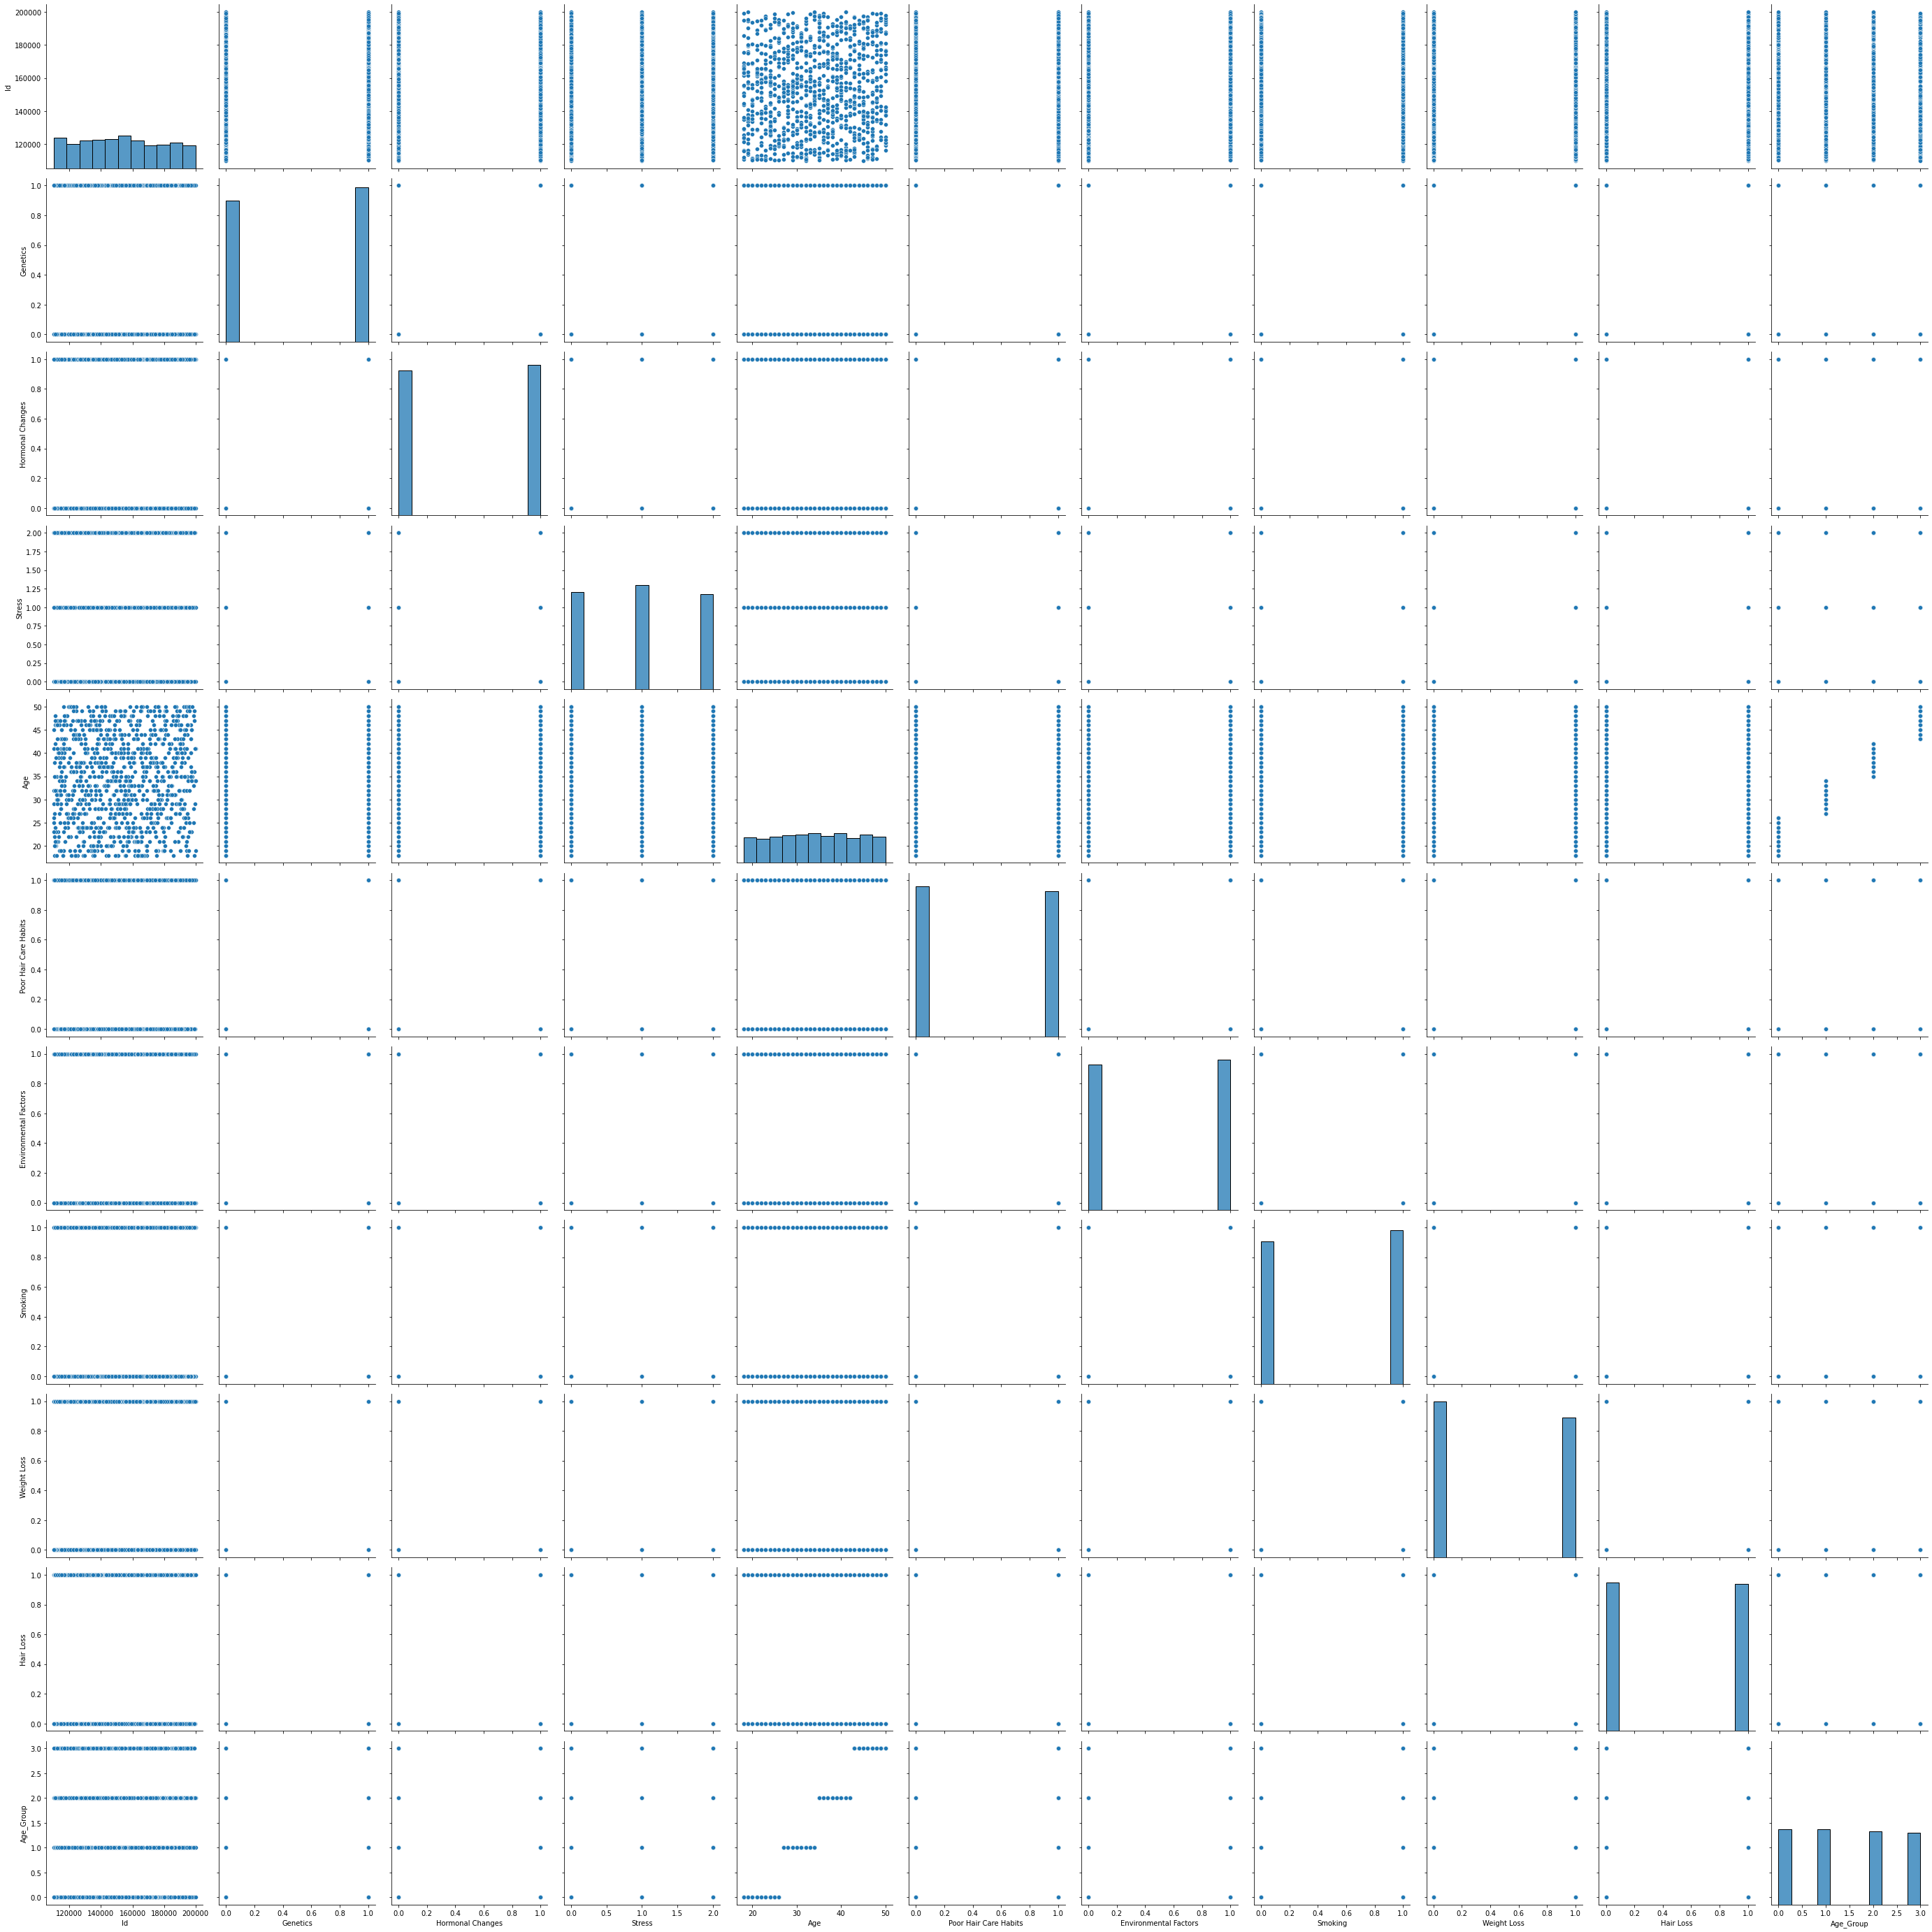

In [91]:
sns.pairplot(df, height=3.5)
plt.tight_layout()
plt.show()


Displaying the heatmap plot... Close the plot window to continue.


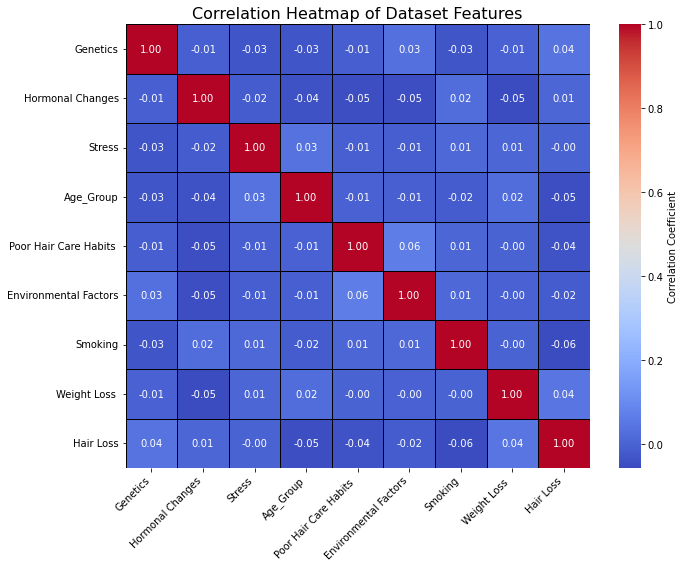

In [92]:
selected_features_for_heatmap = ['Genetics', 'Hormonal Changes', 'Stress', 'Age_Group', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 'Weight Loss ', 'Hair Loss']
correlation_matrix = df[selected_features_for_heatmap].corr()

plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=.5,
    linecolor='black',
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('Correlation Heatmap of Dataset Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
print("\nDisplaying the heatmap plot... Close the plot window to continue.")
plt.show()

In [93]:
#One-hot encode Medical Conditions, Medications & TreatMents, Nutritional Deficiencies
df = pd.get_dummies(df, columns=['Medical Conditions', 'Medications & Treatments','Nutritional Deficiencies '])
df = df.astype(np.float32)

In [94]:
# Define features and target
features = [item for item in list(df.columns) if item not in ['Id','Hair Loss']]

#Check dataset before splitting
print(features)
df.head()

['Genetics', 'Hormonal Changes', 'Stress', 'Age', 'Poor Hair Care Habits ', 'Environmental Factors', 'Smoking', 'Weight Loss ', 'Age_Group', 'Medical Conditions_Alopecia Areata ', 'Medical Conditions_Androgenetic Alopecia', 'Medical Conditions_Dermatitis', 'Medical Conditions_Dermatosis', 'Medical Conditions_Eczema', 'Medical Conditions_MISSING', 'Medical Conditions_Psoriasis', 'Medical Conditions_Ringworm', 'Medical Conditions_Scalp Infection', 'Medical Conditions_Seborrheic Dermatitis', 'Medical Conditions_Thyroid Problems', 'Medications & Treatments_Accutane', 'Medications & Treatments_Antibiotics', 'Medications & Treatments_Antidepressants ', 'Medications & Treatments_Antifungal Cream', 'Medications & Treatments_Blood Pressure Medication', 'Medications & Treatments_Chemotherapy', 'Medications & Treatments_Heart Medication ', 'Medications & Treatments_Immunomodulators', 'Medications & Treatments_MISSING', 'Medications & Treatments_Rogaine', 'Medications & Treatments_Steroids', 'Nutr

,Id,Genetics,Hormonal Changes,Stress,Age,Poor Hair Care Habits,Environmental Factors,Smoking,Weight Loss,Hair Loss,...,Nutritional Deficiencies _Iron deficiency,Nutritional Deficiencies _MISSING,Nutritional Deficiencies _Magnesium deficiency,Nutritional Deficiencies _Omega-3 fatty acids,Nutritional Deficiencies _Protein deficiency,Nutritional Deficiencies _Selenium deficiency,Nutritional Deficiencies _Vitamin A Deficiency,Nutritional Deficiencies _Vitamin D Deficiency,Nutritional Deficiencies _Vitamin E deficiency,Nutritional Deficiencies _Zinc Deficiency
0,133992.0,1.0,0.0,1.0,19.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,148393.0,0.0,0.0,2.0,43.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,155074.0,0.0,0.0,1.0,26.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,118261.0,1.0,1.0,1.0,46.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,111915.0,0.0,0.0,1.0,30.0,0.0,1.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
X = df[features]
y = df['Hair Loss']

# First split: separate test set (10% of data)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# Second split: divide remaining data into train and validation (89% train, 11% validation of remaining data)
# This will give us approximately 80-10-10 split of the total data
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
)

# Print the shapes of the resulting sets
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)

# Calculate and print the percentages
total_samples = len(df)
print("\nData split percentages:")
print(f"Training: {len(X_train)/total_samples:.1%}")
print(f"Validation: {len(X_val)/total_samples:.1%}")
print(f"Test: {len(X_test)/total_samples:.1%}")


Training set shape: (799, 42)
Validation set shape: (100, 42)
Test set shape: (100, 42)

Data split percentages:
Training: 80.0%
Validation: 10.0%
Test: 10.0%


In [96]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Fit on training data 
X_train_scaled = scaler.fit_transform(X_train)

# Transform validation and test sets
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

In [97]:
from sklearn.linear_model import LogisticRegression
# LASSO Logistic Regression 
lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',   
    max_iter=2000,       
    random_state=42,
    class_weight='balanced'   
)

# Ridge Logistic Regression
ridge_model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',       
    max_iter=2000,
    random_state=42,
    class_weight='balanced'  
)

In [98]:
#fitting the models
lasso_model.fit(X_train_scaled, y_train)
ridge_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)

In [99]:
from sklearn.metrics import(accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,log_loss,brier_score_loss,classification_report,confusion_matrix)
# Training predictions
lasso_train_pred = lasso_model.predict(X_train_scaled)
ridge_train_pred = ridge_model.predict(X_train_scaled)
print("=========== LASSO Logistic Regression Results ===========")
# Validation predictions
lasso_val_pred = lasso_model.predict(X_val_scaled)
ridge_val_pred = ridge_model.predict(X_val_scaled)

# Training metrics
lasso_train_proba = lasso_model.predict_proba(X_train_scaled)[:, 1]
print("\n--- TRAINING SET ---")
print("Accuracy       :", accuracy_score(y_train, lasso_train_pred))
print("Precision      :", precision_score(y_train, lasso_train_pred, zero_division=0))
print("Recall         :", recall_score(y_train, lasso_train_pred, zero_division=0))
print("F1 Score       :", f1_score(y_train, lasso_train_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_train, lasso_train_proba))
print("Log Loss       :", log_loss(y_train, lasso_train_proba))
print("Brier Score    :", brier_score_loss(y_train, lasso_train_proba))

# Validation metrics
lasso_val_proba = lasso_model.predict_proba(X_val_scaled)[:, 1]
print("\n--- VALIDATION SET ---")
print("Accuracy       :", accuracy_score(y_val, lasso_val_pred))
print("Precision      :", precision_score(y_val, lasso_val_pred, zero_division=0))
print("Recall         :", recall_score(y_val, lasso_val_pred, zero_division=0))
print("F1 Score       :", f1_score(y_val, lasso_val_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_val, lasso_val_proba))
print("Log Loss       :", log_loss(y_val, lasso_val_proba))
print("Brier Score    :", brier_score_loss(y_val, lasso_val_proba))

print("============================================")

print("Ridge Logistic Regression Results")
# Training metrics
ridge_train_proba = ridge_model.predict_proba(X_train_scaled)[:, 1]
print("\n--- TRAINING SET ---")
print("Accuracy       :", accuracy_score(y_train, ridge_train_pred))
print("Precision      :", precision_score(y_train, ridge_train_pred, zero_division=0))
print("Recall         :", recall_score(y_train, ridge_train_pred, zero_division=0))
print("F1 Score       :", f1_score(y_train, ridge_train_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_train, ridge_train_proba))
print("Log Loss       :", log_loss(y_train, ridge_train_proba))
print("Brier Score    :", brier_score_loss(y_train, ridge_train_proba))

# Validation metrics
ridge_val_proba = ridge_model.predict_proba(X_val_scaled)[:, 1]
print("\n--- VALIDATION SET ---")
print("Accuracy       :", accuracy_score(y_val, ridge_val_pred))
print("Precision      :", precision_score(y_val, ridge_val_pred, zero_division=0))
print("Recall         :", recall_score(y_val, ridge_val_pred, zero_division=0))
print("F1 Score       :", f1_score(y_val, ridge_val_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_val, ridge_val_proba))
print("Log Loss       :", log_loss(y_val, ridge_val_proba))
print("Brier Score    :", brier_score_loss(y_val, ridge_val_proba))

=========== LASSO Logistic Regression Results ===========

--- TRAINING SET ---
Accuracy       : 0.5932415519399249
Precision      : 0.5913705583756346
Recall         : 0.5869017632241813
F1 Score       : 0.5891276864728192
ROC–AUC        : 0.6186761407070441
Log Loss       : 0.6706608091645185
Brier Score    : 0.23901659251775953

--- VALIDATION SET ---
Accuracy       : 0.5
Precision      : 0.5
Recall         : 0.54
F1 Score       : 0.5192307692307693
ROC–AUC        : 0.48839999999999995
Log Loss       : 0.7167727598586037
Brier Score    : 0.26118929357439674
Ridge Logistic Regression Results

--- TRAINING SET ---
Accuracy       : 0.5957446808510638
Precision      : 0.5939086294416244
Recall         : 0.5894206549118388
F1 Score       : 0.5916561314791404
ROC–AUC        : 0.6193215283782598
Log Loss       : 0.6703840715542573
Brier Score    : 0.23888946859680513

--- VALIDATION SET ---
Accuracy       : 0.5
Precision      : 0.5
Recall         : 0.54
F1 Score       : 0.5192307692307693


In [100]:
lasso_val_acc = accuracy_score(y_val, lasso_val_pred)
ridge_val_acc = accuracy_score(y_val, ridge_val_pred)

In [101]:
if ridge_val_acc > lasso_val_acc:
    best_model = ridge_model
    best_name = "Ridge (L2)"
else:
    best_model = lasso_model
    best_name = "LASSO (L1)"

print("\nBest model selected:", best_name)


Best model selected: LASSO (L1)


In [102]:
test_pred = best_model.predict(X_test_scaled)

In [103]:
print("LOGISTIC REGRESSION – TEST SET PERFORMANCE")
# 1. Predictions
y_test_pred = best_model.predict(X_test_scaled)
# 2. Probabilities for class 1 (Hair Loss)
y_test_proba = best_model.predict_proba(X_test_scaled)[:, 1]
# 3. Metrics
acc = accuracy_score(y_test, y_test_pred)
prec= precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1  = f1_score(y_test, y_test_pred, zero_division=0)
auc = roc_auc_score(y_test, y_test_proba)
ll  = log_loss(y_test, y_test_proba)
brier = brier_score_loss(y_test, y_test_proba)

# 4. Print results
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC–AUC        : {auc:.4f}")
print(f"Log Loss       : {ll:.4f}")
print(f"Brier Score    : {brier:.4f}")



# 5. Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))

LOGISTIC REGRESSION – TEST SET PERFORMANCE
Accuracy       : 0.4900
Precision      : 0.4912
Recall         : 0.5600
F1 Score       : 0.5234
ROC–AUC        : 0.4484
Log Loss       : 0.7404
Brier Score    : 0.2722

Confusion Matrix:
[[21 29]
 [22 28]]


In [104]:
test_acc = accuracy_score(y_test, test_pred)
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.49


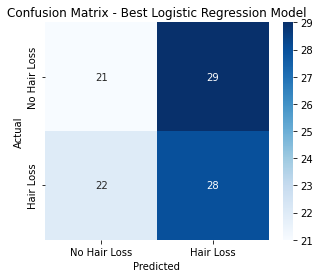

In [105]:
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Hair Loss','Hair Loss'],
    yticklabels=['No Hair Loss','Hair Loss']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best Logistic Regression Model")
plt.show()

In [106]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [107]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_linear = LinearSVC(C=1.0, class_weight='balanced',  max_iter=10000)
svm_model = CalibratedClassifierCV(svm_linear)
svm_model.fit(X_train_scaled, y_train)

CalibratedClassifierCV(base_estimator=LinearSVC(class_weight='balanced',
                                                max_iter=10000))

In [108]:
y_val_pred_svm = svm_model.predict(X_val_scaled)
val_acc_svm = accuracy_score(y_val, y_val_pred_svm)

print("=========== SVM (RBF) Results ===========")

# Training predictions & probabilities
svm_train_pred  = svm_model.predict(X_train_scaled)
svm_train_proba = svm_model.predict_proba(X_train_scaled)[:, 1]

print("\n--- TRAINING SET ---")
print("Accuracy       :", accuracy_score(y_train, svm_train_pred))
print("Precision      :", precision_score(y_train, svm_train_pred, zero_division=0))
print("Recall         :", recall_score(y_train, svm_train_pred, zero_division=0))
print("F1 Score       :", f1_score(y_train, svm_train_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_train, svm_train_proba))
print("Log Loss       :", log_loss(y_train, svm_train_proba))
print("Brier Score    :", brier_score_loss(y_train, svm_train_proba))

# Validation predictions & probabilities
svm_val_pred  = svm_model.predict(X_val_scaled)
svm_val_proba = svm_model.predict_proba(X_val_scaled)[:, 1]

print("\n--- VALIDATION SET ---")
print("Accuracy       :", accuracy_score(y_val, svm_val_pred))
print("Precision      :", precision_score(y_val, svm_val_pred, zero_division=0))
print("Recall         :", recall_score(y_val, svm_val_pred, zero_division=0))
print("F1 Score       :", f1_score(y_val, svm_val_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_val, svm_val_proba))
print("Log Loss       :", log_loss(y_val, svm_val_proba))
print("Brier Score    :", brier_score_loss(y_val, svm_val_proba))

=========== SVM (RBF) Results ===========

--- TRAINING SET ---
Accuracy       : 0.409261576971214
Precision      : 0.3937677053824363
Recall         : 0.3501259445843829
F1 Score       : 0.3706666666666667
ROC–AUC        : 0.3837362306853641
Log Loss       : 0.7032573419911095
Brier Score    : 0.2550459865200159

--- VALIDATION SET ---
Accuracy       : 0.5
Precision      : 0.5
Recall         : 0.46
F1 Score       : 0.4791666666666667
ROC–AUC        : 0.5304
Log Loss       : 0.691683882421945
Brier Score    : 0.24927001214637845


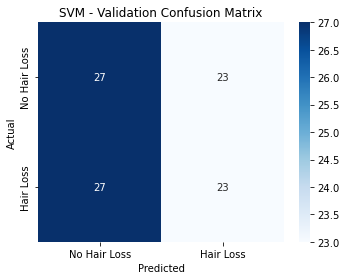

In [109]:
cm = confusion_matrix(y_val, y_val_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Hair Loss', 'Hair Loss'],
    yticklabels=['No Hair Loss', 'Hair Loss']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [110]:
print("SVM – TEST SET PERFORMANCE")

# 1. Class predictions
y_test_pred_svm = svm_model.predict(X_test_scaled)

# 2. Probability predictions (requires probability=True)
y_test_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# 3. Metrics
acc = accuracy_score(y_test, y_test_pred_svm)
prec= precision_score(y_test, y_test_pred_svm, zero_division=0)
rec = recall_score(y_test, y_test_pred_svm, zero_division=0)
f1  = f1_score(y_test, y_test_pred_svm, zero_division=0)
auc = roc_auc_score(y_test, y_test_proba_svm)
ll  = log_loss(y_test, y_test_proba_svm)
brier = brier_score_loss(y_test, y_test_proba_svm)

# 4. Print results
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC–AUC        : {auc:.4f}")
print(f"Log Loss       : {ll:.4f}")
print(f"Brier Score    : {brier:.4f}")



# 5. Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_svm))

SVM – TEST SET PERFORMANCE
Accuracy       : 0.5000
Precision      : 0.5000
Recall         : 0.3800
F1 Score       : 0.4318
ROC–AUC        : 0.5384
Log Loss       : 0.6888
Brier Score    : 0.2479

Confusion Matrix:
[[31 19]
 [31 19]]


SVM ROC–AUC: 0.5384


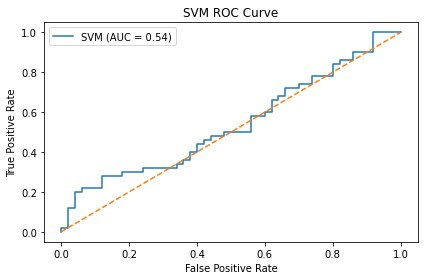

In [111]:
from sklearn.metrics import roc_auc_score, roc_curve

y_test_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]
auc_svm = roc_auc_score(y_test, y_test_prob_svm)
print("SVM ROC–AUC:", auc_svm)

fpr, tpr, _ = roc_curve(y_test, y_test_prob_svm)

plt.figure()
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [112]:
from sklearn.neighbors import KNeighborsClassifier

In [113]:
k_values = range(1, 101, 2) 

best_k = None
best_val_acc = 0.0
best_knn_model = None

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='uniform',
        metric='minkowski',
        p=2
    )
    
    knn.fit(X_train_scaled, y_train)
    y_val_pred = knn.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    print(f"k = {k}: Validation Accuracy = {val_acc:.4f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_k = k
        best_knn_model = knn  


print("Best k selected:", best_k)
print("Best validation accuracy:", best_val_acc)

final_knn_model = best_knn_model

k = 1: Validation Accuracy = 0.5200
k = 3: Validation Accuracy = 0.5300
k = 5: Validation Accuracy = 0.5000
k = 7: Validation Accuracy = 0.5100
k = 9: Validation Accuracy = 0.5000
k = 11: Validation Accuracy = 0.4700
k = 13: Validation Accuracy = 0.4600
k = 15: Validation Accuracy = 0.4600
k = 17: Validation Accuracy = 0.5000
k = 19: Validation Accuracy = 0.4900
k = 21: Validation Accuracy = 0.4400
k = 23: Validation Accuracy = 0.4700
k = 25: Validation Accuracy = 0.4400
k = 27: Validation Accuracy = 0.4900
k = 29: Validation Accuracy = 0.4800
k = 31: Validation Accuracy = 0.5000
k = 33: Validation Accuracy = 0.5300
k = 35: Validation Accuracy = 0.4700
k = 37: Validation Accuracy = 0.5000
k = 39: Validation Accuracy = 0.5400
k = 41: Validation Accuracy = 0.5200
k = 43: Validation Accuracy = 0.5200
k = 45: Validation Accuracy = 0.5100
k = 47: Validation Accuracy = 0.5000
k = 49: Validation Accuracy = 0.4700
k = 51: Validation Accuracy = 0.5100
k = 53: Validation Accuracy = 0.5600
k = 55

In [114]:
y_val_pred_knn = final_knn_model.predict(X_val_scaled)
y_test_pred_knn = final_knn_model.predict(X_test_scaled)

val_acc_knn = accuracy_score(y_val, y_val_pred_knn)
print("\n=========== KNN Results ===========")

# Training predictions & probabilities
knn_train_pred  = final_knn_model.predict(X_train_scaled)
knn_train_proba = final_knn_model.predict_proba(X_train_scaled)[:, 1]

print("\n--- TRAINING SET ---")
print("Accuracy       :", accuracy_score(y_train, knn_train_pred))
print("Precision      :", precision_score(y_train, knn_train_pred, zero_division=0))
print("Recall         :", recall_score(y_train, knn_train_pred, zero_division=0))
print("F1 Score       :", f1_score(y_train, knn_train_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_train, knn_train_proba))
print("Log Loss       :", log_loss(y_train, knn_train_proba))
print("Brier Score    :", brier_score_loss(y_train, knn_train_proba))

# Validation predictions & probabilities
knn_val_pred  = final_knn_model.predict(X_val_scaled)
knn_val_proba = final_knn_model.predict_proba(X_val_scaled)[:, 1]

print("\n--- VALIDATION SET ---")
print("Accuracy       :", accuracy_score(y_val, knn_val_pred))
print("Precision      :", precision_score(y_val, knn_val_pred, zero_division=0))
print("Recall         :", recall_score(y_val, knn_val_pred, zero_division=0))
print("F1 Score       :", f1_score(y_val, knn_val_pred, zero_division=0))
print("ROC–AUC        :", roc_auc_score(y_val, knn_val_proba))
print("Log Loss       :", log_loss(y_val, knn_val_proba))
print("Brier Score    :", brier_score_loss(y_val, knn_val_proba))


=========== KNN Results ===========

--- TRAINING SET ---
Accuracy       : 0.523153942428035
Precision      : 0.5202020202020202
Recall         : 0.5188916876574308
F1 Score       : 0.5195460277427492
ROC–AUC        : 0.5378272366129052
Log Loss       : 0.6916262942774075
Brier Score    : 0.2492644998130896

--- VALIDATION SET ---
Accuracy       : 0.56
Precision      : 0.5555555555555556
Recall         : 0.6
F1 Score       : 0.576923076923077
ROC–AUC        : 0.487
Log Loss       : 0.7073891703778269
Brier Score    : 0.2569241723033107


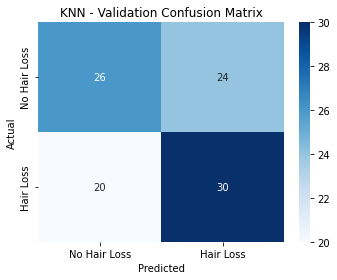

In [115]:
cm = confusion_matrix(y_val, y_val_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Hair Loss', 'Hair Loss'],
    yticklabels=['No Hair Loss', 'Hair Loss']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [116]:
k_values = range(1, 101,2)
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(
        n_neighbors=k,
        weights='uniform',
        metric='minkowski',
        p=2                     
    )
    
    knn.fit(X_train_scaled, y_train)
    
    y_val_pred = knn.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_val_pred)
    
    val_accuracies.append(acc)
    print(f"k = {k}: Validation Accuracy = {acc:.4f}")


k = 1: Validation Accuracy = 0.5200
k = 3: Validation Accuracy = 0.5300
k = 5: Validation Accuracy = 0.5000
k = 7: Validation Accuracy = 0.5100
k = 9: Validation Accuracy = 0.5000
k = 11: Validation Accuracy = 0.4700
k = 13: Validation Accuracy = 0.4600
k = 15: Validation Accuracy = 0.4600
k = 17: Validation Accuracy = 0.5000
k = 19: Validation Accuracy = 0.4900
k = 21: Validation Accuracy = 0.4400
k = 23: Validation Accuracy = 0.4700
k = 25: Validation Accuracy = 0.4400
k = 27: Validation Accuracy = 0.4900
k = 29: Validation Accuracy = 0.4800
k = 31: Validation Accuracy = 0.5000
k = 33: Validation Accuracy = 0.5300
k = 35: Validation Accuracy = 0.4700
k = 37: Validation Accuracy = 0.5000
k = 39: Validation Accuracy = 0.5400
k = 41: Validation Accuracy = 0.5200
k = 43: Validation Accuracy = 0.5200
k = 45: Validation Accuracy = 0.5100
k = 47: Validation Accuracy = 0.5000
k = 49: Validation Accuracy = 0.4700
k = 51: Validation Accuracy = 0.5100
k = 53: Validation Accuracy = 0.5600
k = 55

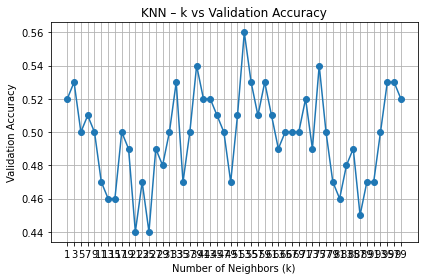

In [117]:
plt.figure(figsize=(6,4))
plt.plot(k_values, val_accuracies, marker='o')
plt.xticks(k_values)
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Validation Accuracy")
plt.title("KNN – k vs Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.show()


In [118]:
k_best = k_values[val_accuracies.index(max(val_accuracies))]
print("Best k:", k_best)

knn_best = KNeighborsClassifier(
    n_neighbors=k_best,
    weights='distance',  
    metric='minkowski',
    p=2                   
)

knn_best.fit(X_train_scaled, y_train)

Best k: 53


KNeighborsClassifier(n_neighbors=53, weights='distance')

In [119]:
print("KNN – TEST SET PERFORMANCE")

# 1. Class predictions
y_test_pred_knn = knn_best.predict(X_test_scaled)

# 2. Probability predictions (KNN supports predict_proba)
y_test_proba_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

# 3. Metrics
acc = accuracy_score(y_test, y_test_pred_knn)
prec = precision_score(y_test, y_test_pred_knn, zero_division=0)
rec  = recall_score(y_test, y_test_pred_knn, zero_division=0)
f1   = f1_score(y_test, y_test_pred_knn, zero_division=0)
auc  = roc_auc_score(y_test, y_test_proba_knn)
ll   = log_loss(y_test, y_test_proba_knn)
brie = brier_score_loss(y_test, y_test_proba_knn)

# 4. Print results
print(f"Accuracy       : {acc:.4f}")
print(f"Precision      : {prec:.4f}")
print(f"Recall         : {rec:.4f}")
print(f"F1 Score       : {f1:.4f}")
print(f"ROC–AUC        : {auc:.4f}")
print(f"Log Loss       : {ll:.4f}")
print(f"Brier Score    : {brier:.4f}")

# 5. Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_knn))

KNN – TEST SET PERFORMANCE
Accuracy       : 0.5100
Precision      : 0.5088
Recall         : 0.5800
F1 Score       : 0.5421
ROC–AUC        : 0.5404
Log Loss       : 0.6933
Brier Score    : 0.2479

Confusion Matrix:
[[22 28]
 [21 29]]


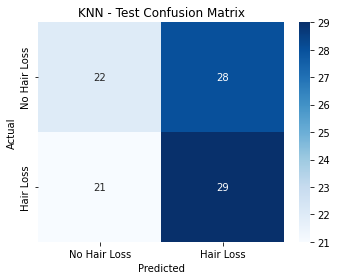

In [120]:
cm_test_knn = confusion_matrix(y_test, y_test_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_test_knn,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Hair Loss', 'Hair Loss'],
    yticklabels=['No Hair Loss', 'Hair Loss']
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN - Test Confusion Matrix")
plt.tight_layout()
plt.show()